=== PHASE 5: DEEP DIVE ANALYSES AND ADVANCED VISUALIZATIONS ===

=== DEEP DIVE 1: THE ANYCAST LATENCY PARADOX ===


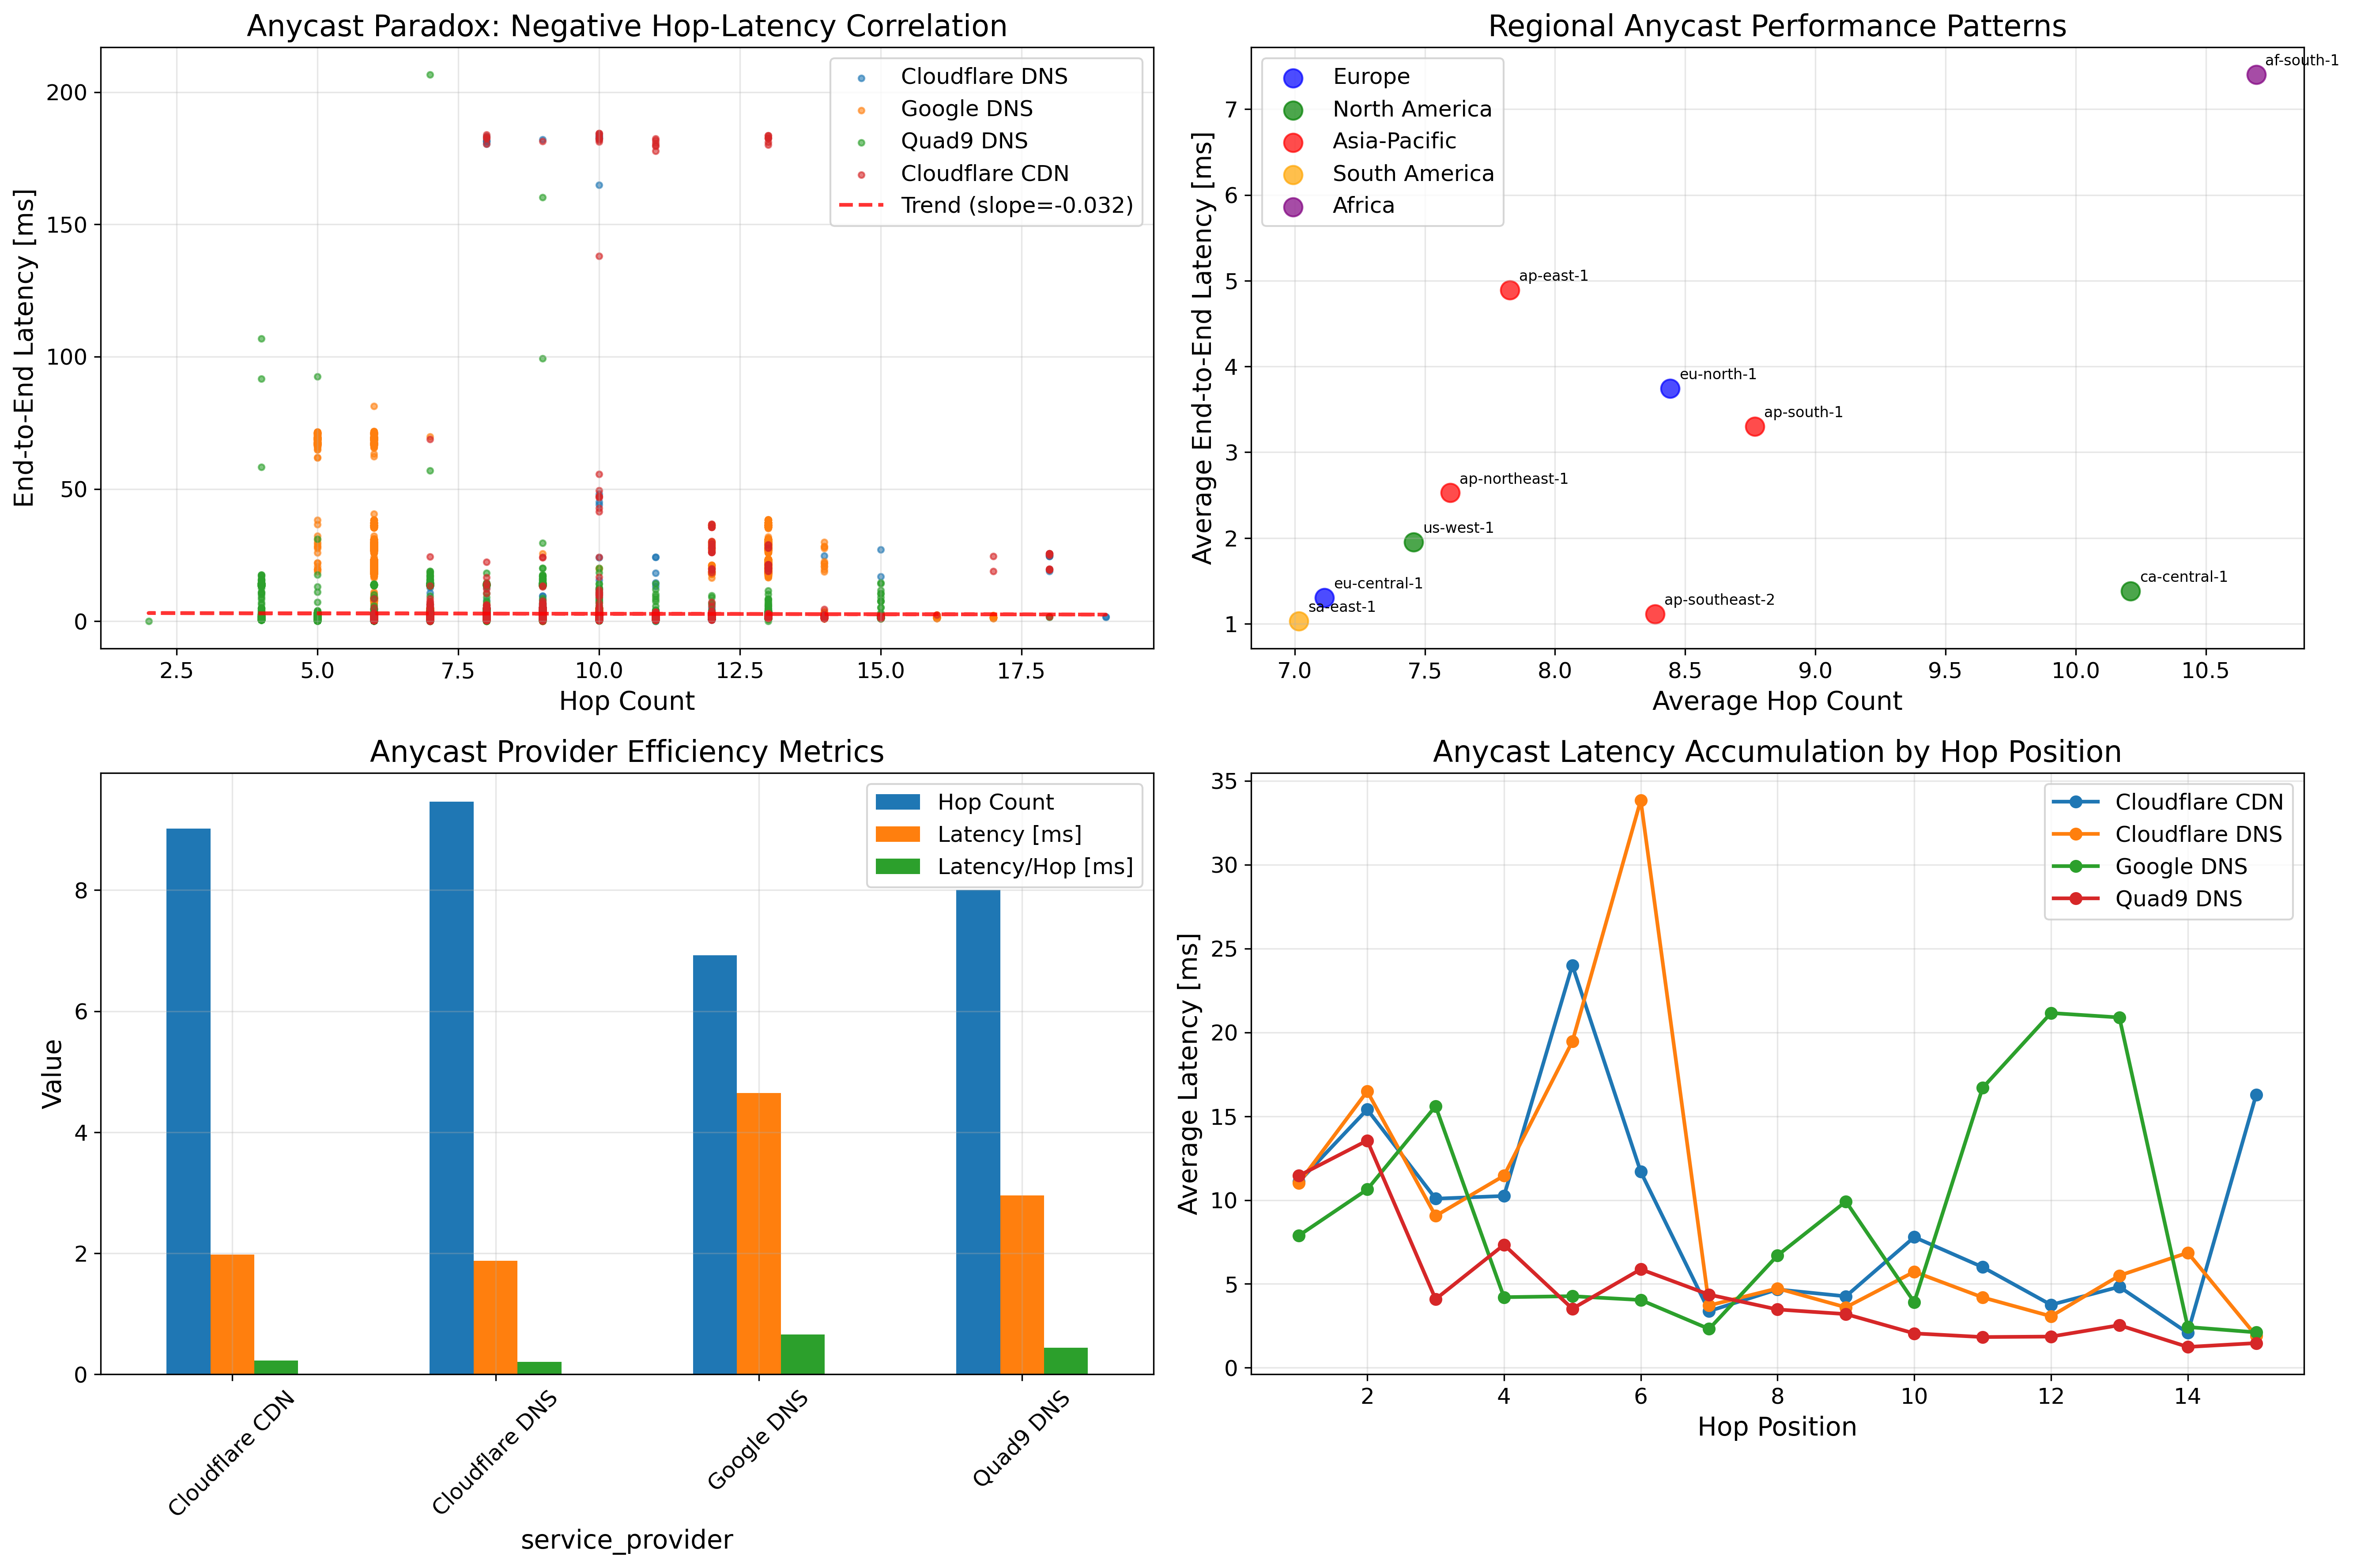

Anycast Paradox Statistical Analysis:
  Cloudflare DNS: r = -0.0242 (p = 2.19e-07, n = 45,978)
  Google DNS: r = 0.2549 (p = 0.00e+00, n = 45,978)
  Quad9 DNS: r = -0.1362 (p = 3.51e-189, n = 45,978)
  Cloudflare CDN: r = 0.0195 (p = 2.98e-05, n = 45,978)

Possible Explanations:
  1. Geographic proximity: Shorter paths to farther anycast nodes
  2. Infrastructure quality: Longer paths through higher-quality networks
  3. Load balancing: Traffic engineering optimizing for latency over hop count
  4. Network topology: Dense interconnection reducing latency despite hop count

=== DEEP DIVE 2: IPv4 vs IPv6 INFRASTRUCTURE COMPARISON ===


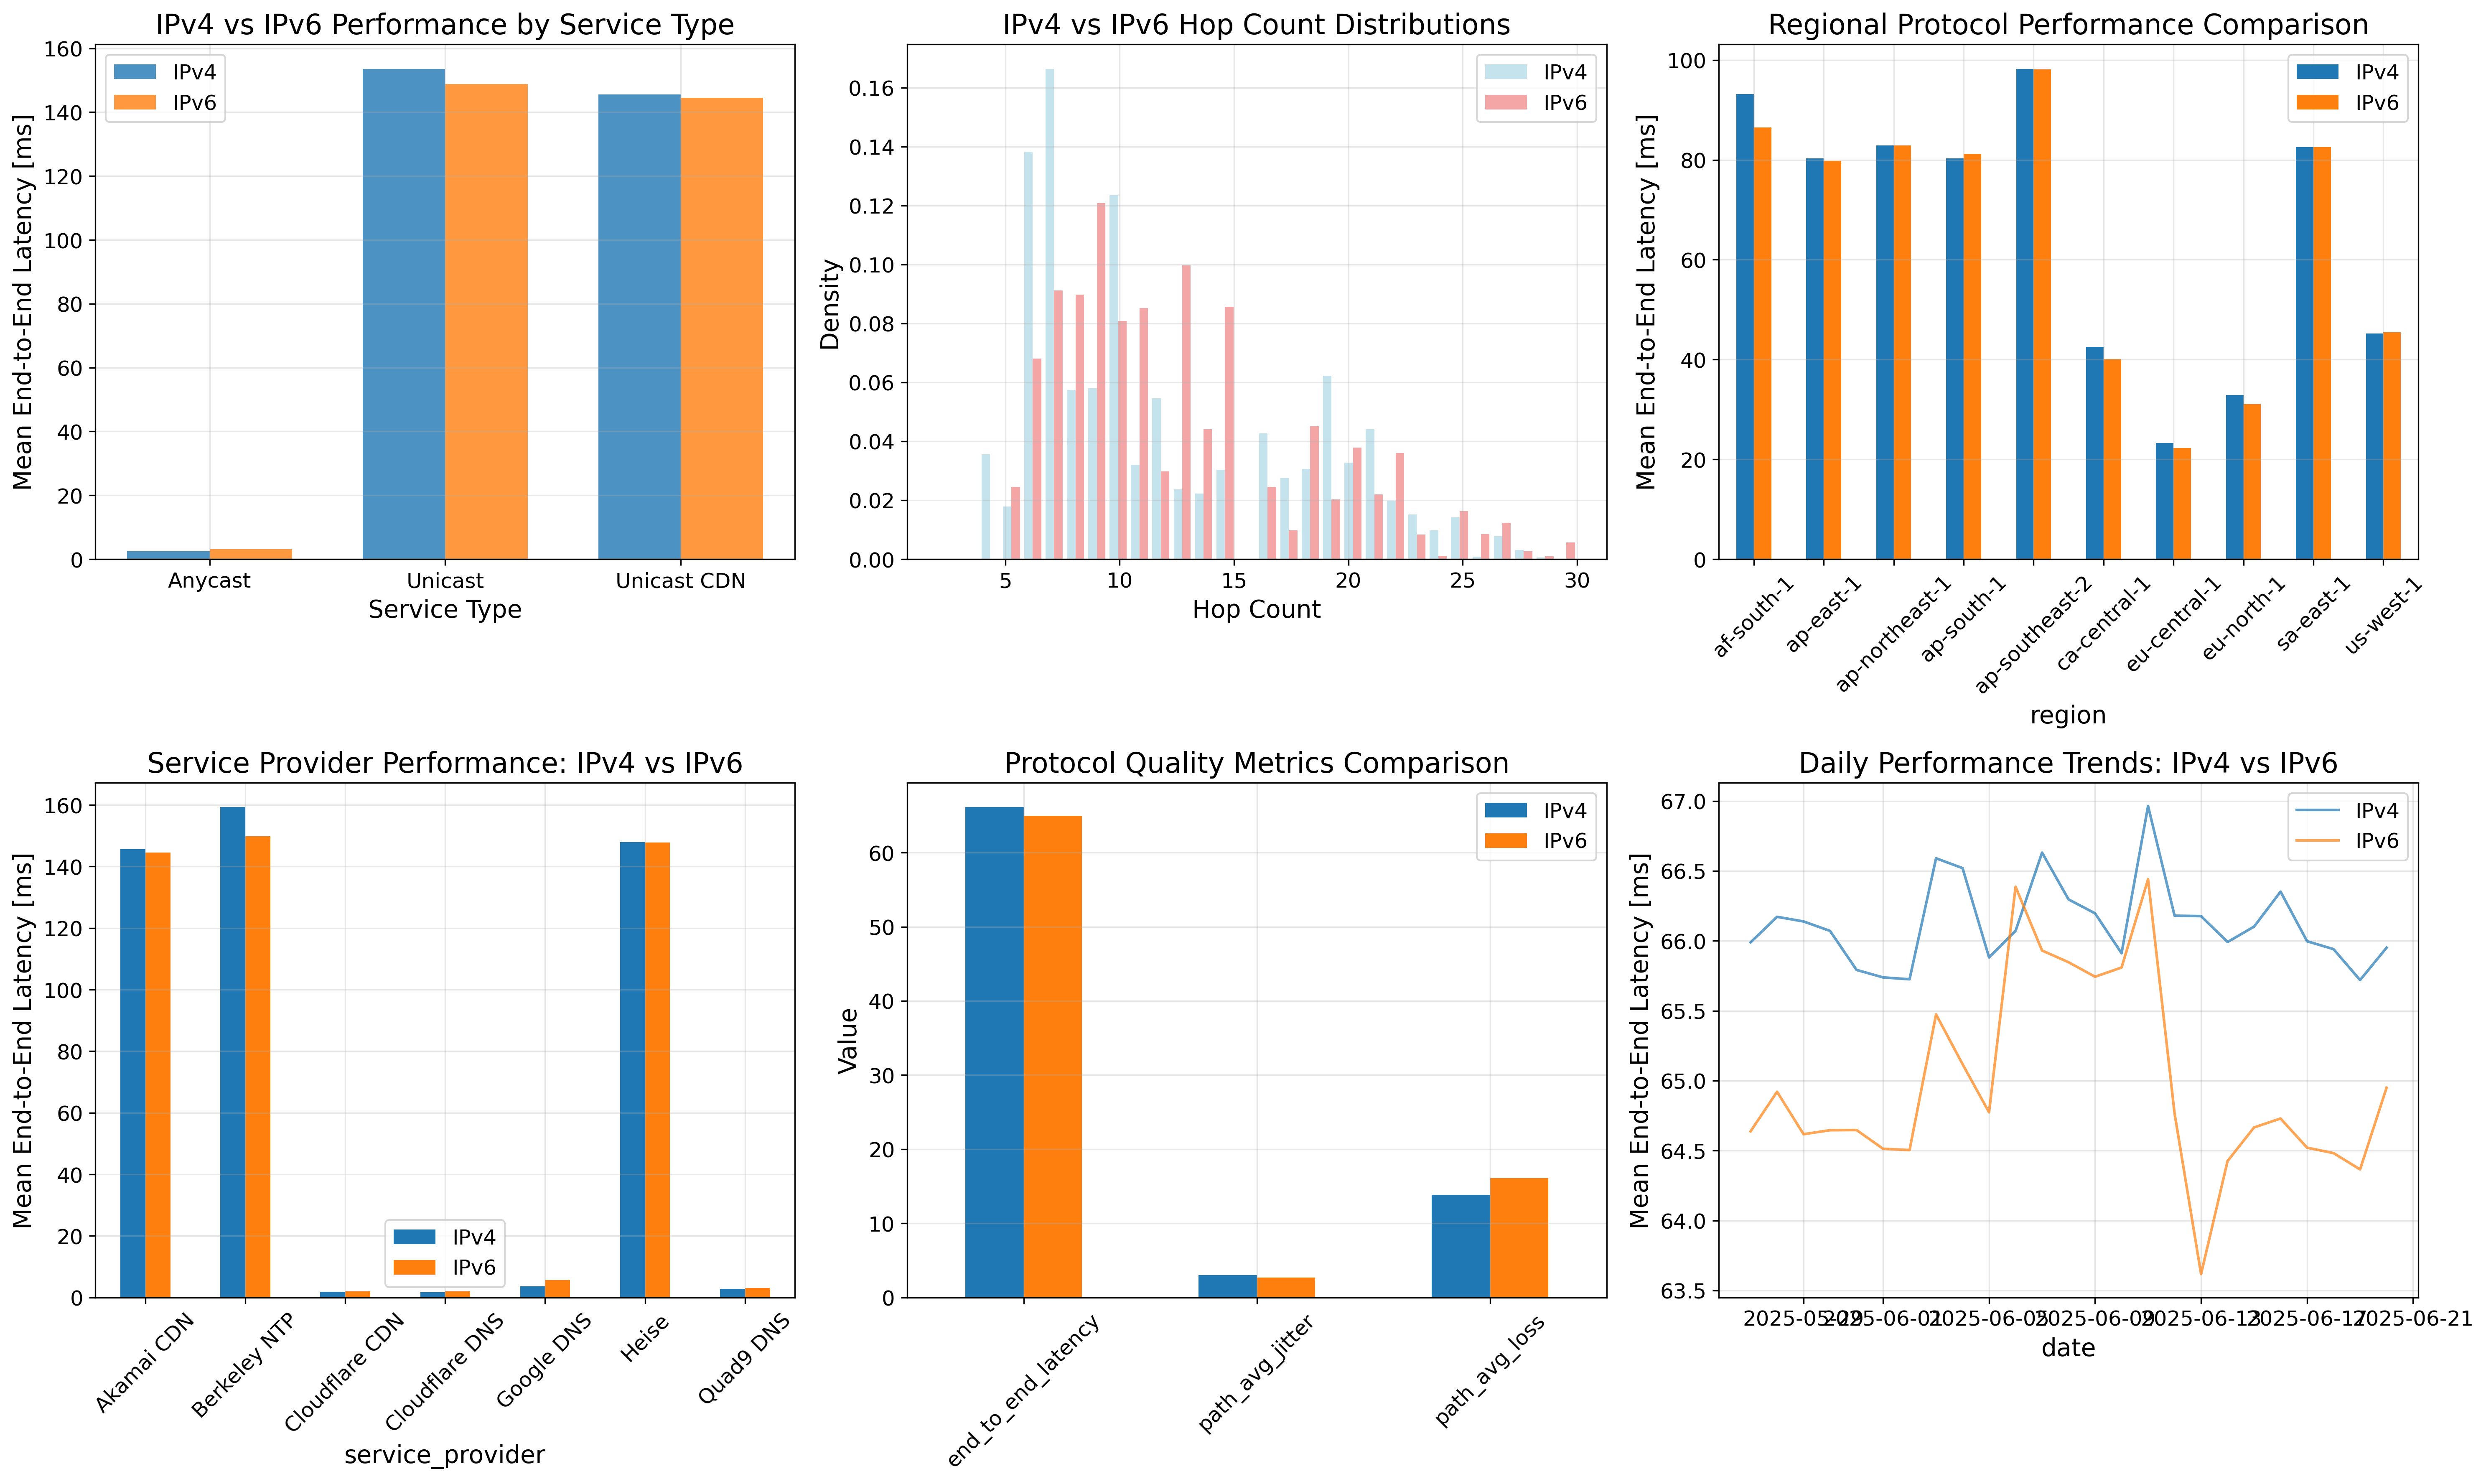

IPv4 vs IPv6 Statistical Comparison:
  end_to_end_latency: Mann-Whitney U p-value = 1.19e-186
  hop_count: Mann-Whitney U p-value = 0.00e+00
  latency_per_hop: Mann-Whitney U p-value = 9.06e-09
  path_avg_jitter: Mann-Whitney U p-value = 7.53e-31

=== DEEP DIVE 3: QoS METRICS ANALYSIS ===


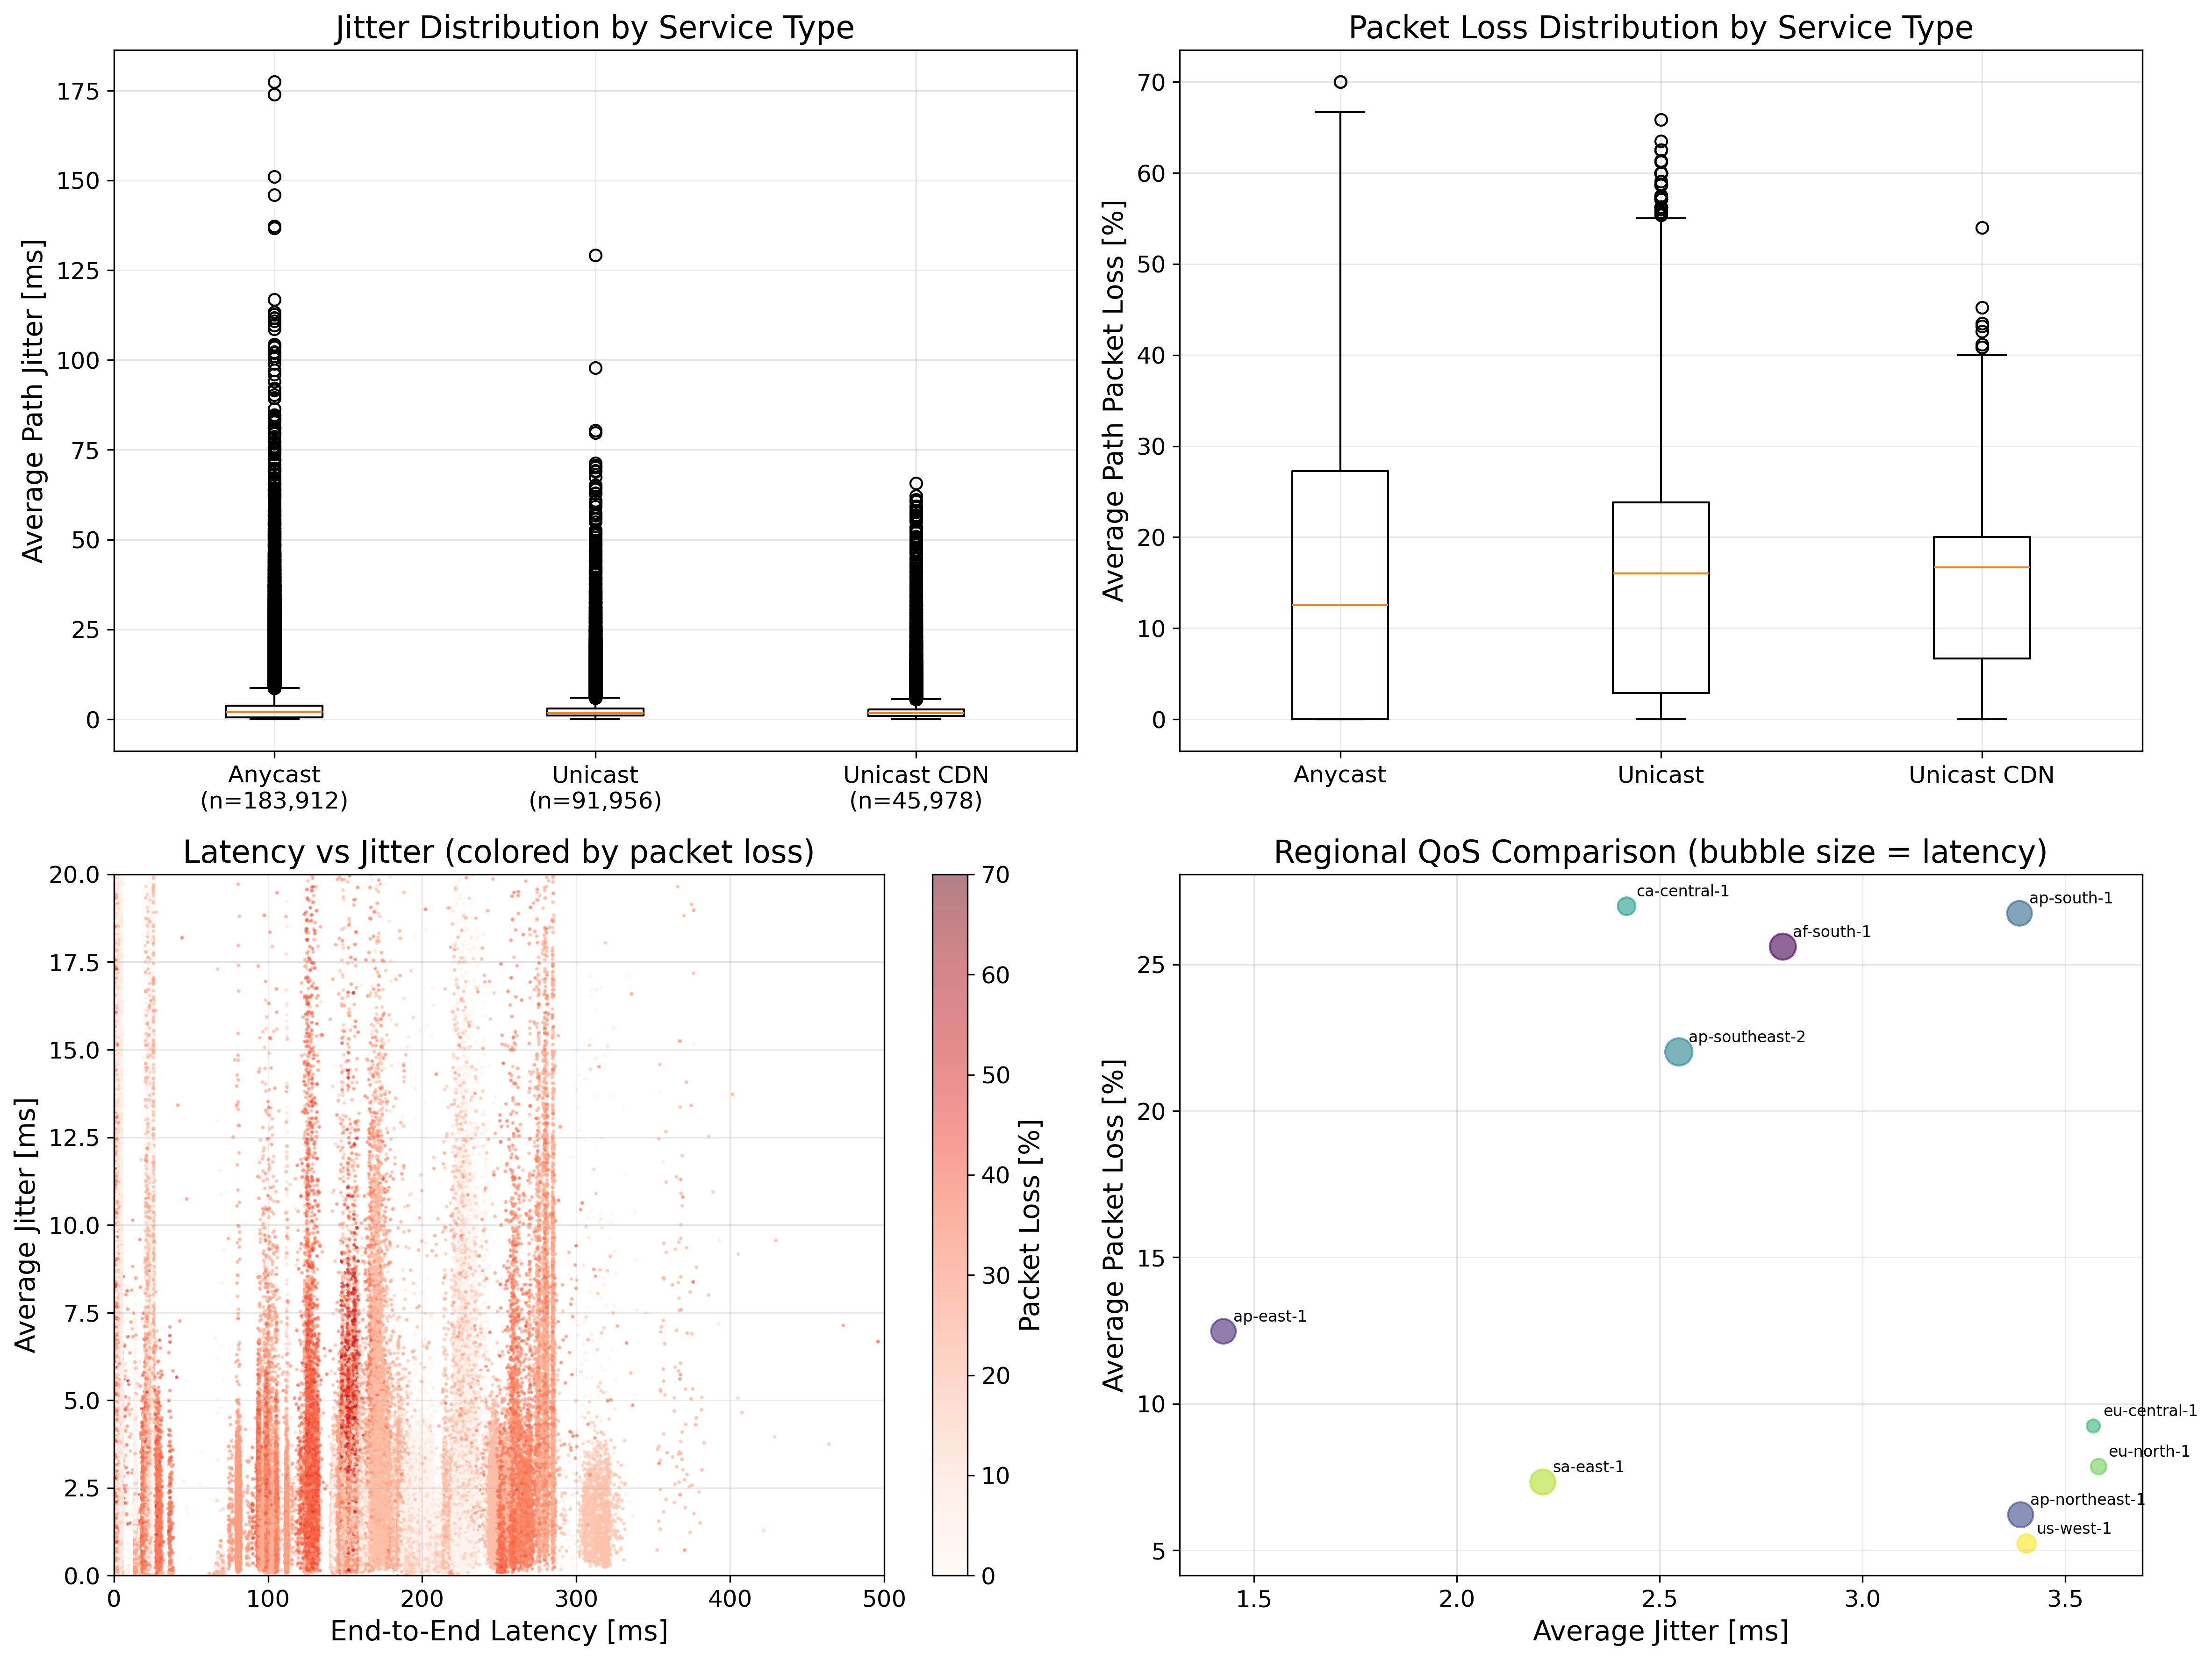

QoS Metrics Summary:
             path_avg_jitter                               path_avg_loss  \
                       count   mean    std median      max         count   
service_type                                                               
Anycast               183912  3.034  4.741  2.072  177.402        183912   
Unicast                91956  2.717  3.627  1.761  129.211         91956   
Unicast CDN            45978  2.547  3.663  1.649   65.670         45978   

                                              
                mean     std  median     max  
service_type                                  
Anycast       14.575  14.651  12.500  70.000  
Unicast       15.716  12.230  16.000  65.833  
Unicast CDN   15.085   9.796  16.667  54.000  

=== DEEP DIVE 4: GOOGLE'S PERFORMANCE EXCELLENCE ===


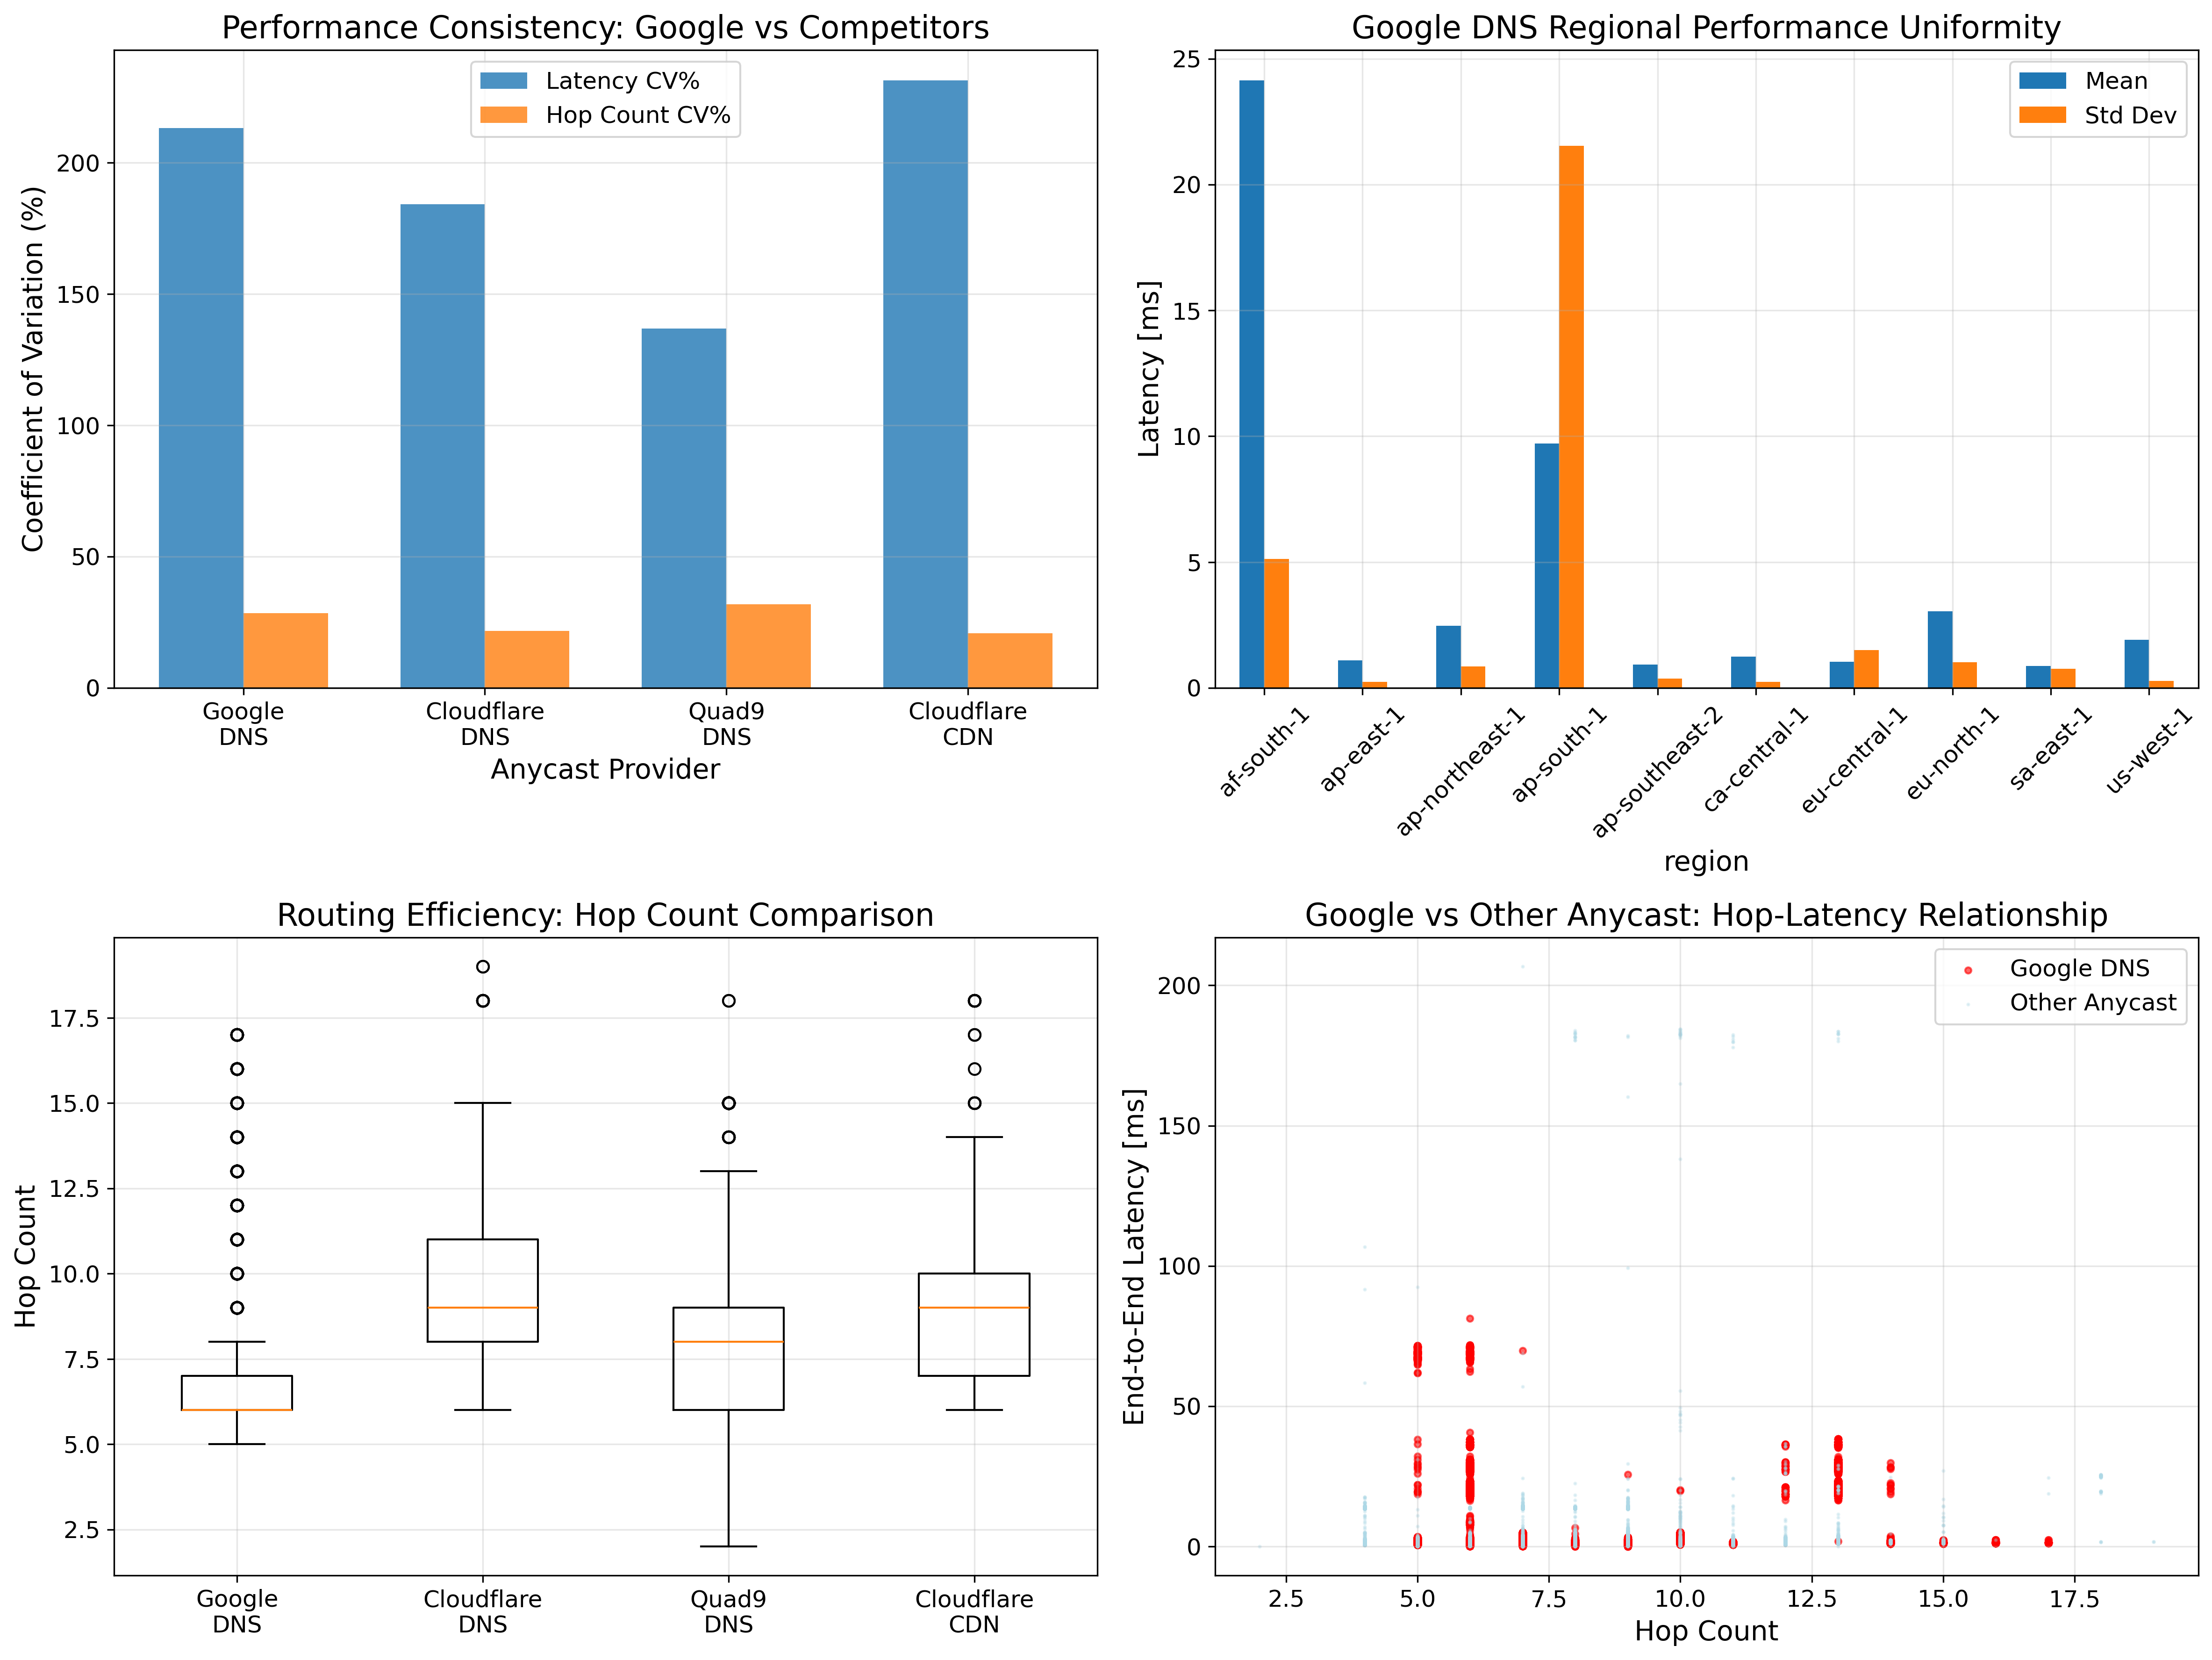

Google DNS Performance Excellence Analysis:
  Mean latency: 4.645ms
  Latency std dev: 9.906ms
  Mean hop count: 6.92
  Hop count std dev: 1.97
  Latency CV: 213.25%
  Hop count CV: 28.42%

=== PHASE 5 COMPLETE ===
All deep dive analyses completed with advanced visualizations
Key findings ready for paper integration


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Set up enhanced plotting
plt.rcParams.update({
    'figure.figsize': (16, 10),
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

print("=== PHASE 5: DEEP DIVE ANALYSES AND ADVANCED VISUALIZATIONS ===")
print()

# Load all results
latency_data = pd.read_csv('../results/latency_analysis.csv')
latency_data['timestamp'] = pd.to_datetime(latency_data['timestamp'])
hop_data = pd.read_csv('../results/hop_by_hop_analysis.csv')

print("=== DEEP DIVE 1: THE ANYCAST LATENCY PARADOX ===")

def analyze_anycast_paradox():
    """Investigate why anycast shows negative hop-latency correlation"""
    anycast_data = latency_data[latency_data['service_type'] == 'Anycast'].copy()
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # 1. Scatter plot showing the paradox
    ax = axes[0, 0]
    for provider in ['Cloudflare DNS', 'Google DNS', 'Quad9 DNS', 'Cloudflare CDN']:
        provider_data = anycast_data[anycast_data['service_provider'] == provider]
        ax.scatter(provider_data['hop_count'], provider_data['end_to_end_latency'], 
                  alpha=0.6, s=10, label=provider)
    
    # Add trend line
    x = anycast_data['hop_count']
    y = anycast_data['end_to_end_latency']
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    ax.plot(x, p(x), "r--", alpha=0.8, linewidth=2, label=f'Trend (slope={z[0]:.3f})')
    
    ax.set_xlabel('Hop Count')
    ax.set_ylabel('End-to-End Latency [ms]')
    ax.set_title('Anycast Paradox: Negative Hop-Latency Correlation')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Regional analysis of the paradox
    ax = axes[0, 1]
    regional_paradox = anycast_data.groupby('region').agg({
        'hop_count': 'mean',
        'end_to_end_latency': 'mean',
        'latency_per_hop': 'mean'
    }).reset_index()
    
    # Color by continent
    region_to_continent = {
        'us-west-1': 'North America', 'ca-central-1': 'North America', 
        'eu-central-1': 'Europe', 'eu-north-1': 'Europe', 'af-south-1': 'Africa',
        'ap-east-1': 'Asia-Pacific', 'ap-south-1': 'Asia-Pacific', 
        'ap-northeast-1': 'Asia-Pacific', 'ap-southeast-2': 'Asia-Pacific',
        'sa-east-1': 'South America'
    }
    regional_paradox['continent'] = regional_paradox['region'].map(region_to_continent)
    
    colors = {'Europe': 'blue', 'North America': 'green', 'Asia-Pacific': 'red', 
              'South America': 'orange', 'Africa': 'purple'}
    
    for continent in colors:
        cont_data = regional_paradox[regional_paradox['continent'] == continent]
        ax.scatter(cont_data['hop_count'], cont_data['end_to_end_latency'], 
                  c=colors[continent], s=100, label=continent, alpha=0.7)
        
        # Add region labels
        for _, row in cont_data.iterrows():
            ax.annotate(row['region'], (row['hop_count'], row['end_to_end_latency']), 
                       xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    ax.set_xlabel('Average Hop Count')
    ax.set_ylabel('Average End-to-End Latency [ms]')
    ax.set_title('Regional Anycast Performance Patterns')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Service provider efficiency analysis
    ax = axes[1, 0]
    provider_efficiency = anycast_data.groupby('service_provider').agg({
        'hop_count': ['mean', 'std'],
        'end_to_end_latency': ['mean', 'std'],
        'latency_per_hop': ['mean', 'std']
    }).round(3)
    
    provider_efficiency.columns = ['_'.join(col) for col in provider_efficiency.columns]
    provider_means = provider_efficiency[['hop_count_mean', 'end_to_end_latency_mean', 'latency_per_hop_mean']]
    
    provider_means.plot(kind='bar', ax=ax)
    ax.set_title('Anycast Provider Efficiency Metrics')
    ax.set_ylabel('Value')
    ax.legend(['Hop Count', 'Latency [ms]', 'Latency/Hop [ms]'])
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    
    # 4. Hop position latency analysis for anycast
    ax = axes[1, 1]
    anycast_hops = hop_data[hop_data['service_type'] == 'Anycast']
    hop_position_avg = anycast_hops[anycast_hops['hop_position'] <= 15].groupby([
        'service_provider', 'hop_position'])['hop_latency'].mean().unstack('hop_position')
    
    for provider in hop_position_avg.index:
        ax.plot(hop_position_avg.columns, hop_position_avg.loc[provider], 
                marker='o', label=provider, linewidth=2)
    
    ax.set_xlabel('Hop Position')
    ax.set_ylabel('Average Latency [ms]')
    ax.set_title('Anycast Latency Accumulation by Hop Position')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../results/anycast_paradox_analysis.png')
    plt.show()
    
    # Statistical analysis
    print("Anycast Paradox Statistical Analysis:")
    for provider in ['Cloudflare DNS', 'Google DNS', 'Quad9 DNS', 'Cloudflare CDN']:
        provider_data = anycast_data[anycast_data['service_provider'] == provider]
        corr, p_val = stats.pearsonr(provider_data['hop_count'], provider_data['end_to_end_latency'])
        print(f"  {provider}: r = {corr:.4f} (p = {p_val:.2e}, n = {len(provider_data):,})")
    
    print("\nPossible Explanations:")
    print("  1. Geographic proximity: Shorter paths to farther anycast nodes")
    print("  2. Infrastructure quality: Longer paths through higher-quality networks")
    print("  3. Load balancing: Traffic engineering optimizing for latency over hop count")
    print("  4. Network topology: Dense interconnection reducing latency despite hop count")

analyze_anycast_paradox()

print()
print("=== DEEP DIVE 2: IPv4 vs IPv6 INFRASTRUCTURE COMPARISON ===")

def compare_ipv4_ipv6_infrastructure():
    """Systematic comparison of IPv4 vs IPv6 infrastructure characteristics"""
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    
    # 1. Protocol performance by service type
    ax = axes[0, 0]
    protocol_performance = latency_data.groupby(['protocol', 'service_type'])['end_to_end_latency'].agg([
        'mean', 'median', 'std']).reset_index()
    
    service_types = ['Anycast', 'Unicast', 'Unicast CDN']
    x = np.arange(len(service_types))
    width = 0.35
    
    ipv4_means = protocol_performance[protocol_performance['protocol'] == 'IPv4']['mean']
    ipv6_means = protocol_performance[protocol_performance['protocol'] == 'IPv6']['mean']
    
    ax.bar(x - width/2, ipv4_means, width, label='IPv4', alpha=0.8)
    ax.bar(x + width/2, ipv6_means, width, label='IPv6', alpha=0.8)
    
    ax.set_xlabel('Service Type')
    ax.set_ylabel('Mean End-to-End Latency [ms]')
    ax.set_title('IPv4 vs IPv6 Performance by Service Type')
    ax.set_xticks(x)
    ax.set_xticklabels(service_types)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Hop count distribution comparison
    ax = axes[0, 1]
    ipv4_hops = latency_data[latency_data['protocol'] == 'IPv4']['hop_count']
    ipv6_hops = latency_data[latency_data['protocol'] == 'IPv6']['hop_count']
    
    ax.hist([ipv4_hops, ipv6_hops], bins=30, alpha=0.7, label=['IPv4', 'IPv6'], 
           density=True, color=['lightblue', 'lightcoral'])
    ax.set_xlabel('Hop Count')
    ax.set_ylabel('Density')
    ax.set_title('IPv4 vs IPv6 Hop Count Distributions')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Regional protocol preferences
    ax = axes[0, 2]
    regional_protocol = latency_data.groupby(['region', 'protocol'])['end_to_end_latency'].mean().unstack()
    regional_protocol.plot(kind='bar', ax=ax)
    ax.set_title('Regional Protocol Performance Comparison')
    ax.set_ylabel('Mean End-to-End Latency [ms]')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(['IPv4', 'IPv6'])
    ax.grid(True, alpha=0.3)
    
    # 4. Service provider protocol efficiency
    ax = axes[1, 0]
    provider_protocol = latency_data.groupby(['service_provider', 'protocol']).agg({
        'end_to_end_latency': 'mean',
        'latency_per_hop': 'mean'
    }).unstack()
    
    provider_protocol['end_to_end_latency'].plot(kind='bar', ax=ax)
    ax.set_title('Service Provider Performance: IPv4 vs IPv6')
    ax.set_ylabel('Mean End-to-End Latency [ms]')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(['IPv4', 'IPv6'])
    ax.grid(True, alpha=0.3)
    
    # 5. Protocol quality metrics comparison
    ax = axes[1, 1]
    quality_metrics = ['end_to_end_latency', 'path_avg_jitter', 'path_avg_loss']
    protocol_quality = latency_data.groupby('protocol')[quality_metrics].mean()
    
    protocol_quality.T.plot(kind='bar', ax=ax)
    ax.set_title('Protocol Quality Metrics Comparison')
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(['IPv4', 'IPv6'])
    ax.grid(True, alpha=0.3)
    
    # 6. Time series comparison
    ax = axes[1, 2]
    latency_data['date'] = latency_data['timestamp'].dt.date
    daily_protocol = latency_data.groupby(['date', 'protocol'])['end_to_end_latency'].mean().unstack()
    daily_protocol.plot(ax=ax, alpha=0.7)
    ax.set_title('Daily Performance Trends: IPv4 vs IPv6')
    ax.set_ylabel('Mean End-to-End Latency [ms]')
    ax.legend(['IPv4', 'IPv6'])
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../results/ipv4_vs_ipv6_infrastructure.png')
    plt.show()
    
    # Statistical comparison
    print("IPv4 vs IPv6 Statistical Comparison:")
    ipv4_data = latency_data[latency_data['protocol'] == 'IPv4']
    ipv6_data = latency_data[latency_data['protocol'] == 'IPv6']
    
    metrics = ['end_to_end_latency', 'hop_count', 'latency_per_hop', 'path_avg_jitter']
    for metric in metrics:
        if metric in ipv4_data.columns:
            stat, p_val = stats.mannwhitneyu(ipv4_data[metric].dropna(), 
                                           ipv6_data[metric].dropna(), 
                                           alternative='two-sided')
            print(f"  {metric}: Mann-Whitney U p-value = {p_val:.2e}")

compare_ipv4_ipv6_infrastructure()

print()
print("=== DEEP DIVE 3: QoS METRICS ANALYSIS ===")

def analyze_qos_metrics():
    """Comprehensive analysis of jitter and packet loss"""
    
    # Filter out zero/invalid values for meaningful analysis
    qos_data = latency_data[(latency_data['path_avg_jitter'] > 0) & 
                           (latency_data['path_avg_loss'] >= 0)].copy()
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Jitter analysis by service type
    ax = axes[0, 0]
    jitter_by_service = []
    service_labels = []
    
    for service_type in ['Anycast', 'Unicast', 'Unicast CDN']:
        service_jitter = qos_data[qos_data['service_type'] == service_type]['path_avg_jitter']
        if len(service_jitter) > 0:
            jitter_by_service.append(service_jitter)
            service_labels.append(f'{service_type}\n(n={len(service_jitter):,})')
    
    ax.boxplot(jitter_by_service, labels=service_labels)
    ax.set_ylabel('Average Path Jitter [ms]')
    ax.set_title('Jitter Distribution by Service Type')
    ax.grid(True, alpha=0.3)
    
    # 2. Packet loss analysis
    ax = axes[0, 1]
    loss_by_service = []
    
    for service_type in ['Anycast', 'Unicast', 'Unicast CDN']:
        service_loss = qos_data[qos_data['service_type'] == service_type]['path_avg_loss']
        if len(service_loss) > 0:
            loss_by_service.append(service_loss)
    
    ax.boxplot(loss_by_service, labels=['Anycast', 'Unicast', 'Unicast CDN'])
    ax.set_ylabel('Average Path Packet Loss [%]')
    ax.set_title('Packet Loss Distribution by Service Type')
    ax.grid(True, alpha=0.3)
    
    # 3. QoS correlation with latency
    ax = axes[1, 0]
    ax.scatter(qos_data['end_to_end_latency'], qos_data['path_avg_jitter'], 
              alpha=0.5, s=1, c=qos_data['path_avg_loss'], cmap='Reds')
    ax.set_xlabel('End-to-End Latency [ms]')
    ax.set_ylabel('Average Jitter [ms]')
    ax.set_title('Latency vs Jitter (colored by packet loss)')
    ax.set_xlim(0, 500)  # Focus on reasonable range
    ax.set_ylim(0, 20)
    cbar = plt.colorbar(ax.collections[0], ax=ax)
    cbar.set_label('Packet Loss [%]')
    ax.grid(True, alpha=0.3)
    
    # 4. Regional QoS comparison
    ax = axes[1, 1]
    regional_qos = qos_data.groupby('region').agg({
        'path_avg_jitter': 'mean',
        'path_avg_loss': 'mean',
        'end_to_end_latency': 'mean'
    })
    
    # Create bubble plot: x=jitter, y=loss, size=latency
    bubble_sizes = regional_qos['end_to_end_latency'] * 2  # Scale for visibility
    scatter = ax.scatter(regional_qos['path_avg_jitter'], regional_qos['path_avg_loss'], 
                        s=bubble_sizes, alpha=0.6, c=range(len(regional_qos)), cmap='viridis')
    
    # Add region labels
    for i, region in enumerate(regional_qos.index):
        ax.annotate(region, (regional_qos.loc[region, 'path_avg_jitter'], 
                           regional_qos.loc[region, 'path_avg_loss']),
                   xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    ax.set_xlabel('Average Jitter [ms]')
    ax.set_ylabel('Average Packet Loss [%]')
    ax.set_title('Regional QoS Comparison (bubble size = latency)')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../results/qos_analysis.png')
    plt.show()
    
    # QoS statistics
    print("QoS Metrics Summary:")
    qos_summary = qos_data.groupby('service_type')[['path_avg_jitter', 'path_avg_loss']].agg([
        'count', 'mean', 'std', 'median', 'max']).round(3)
    print(qos_summary)

if len(latency_data[latency_data['path_avg_jitter'] > 0]) > 0:
    analyze_qos_metrics()
else:
    print("Insufficient QoS data for meaningful analysis")

print()
print("=== DEEP DIVE 4: GOOGLE'S PERFORMANCE EXCELLENCE ===")

def analyze_google_performance():
    """Deep dive into Google's exceptional performance characteristics"""
    google_data = latency_data[latency_data['service_provider'] == 'Google DNS'].copy()
    other_anycast = latency_data[latency_data['service_type'] == 'Anycast'][
        latency_data['service_provider'] != 'Google DNS'].copy()
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Google vs other anycast consistency
    ax = axes[0, 0]
    
    # Calculate coefficient of variation for each provider
    providers = ['Google DNS', 'Cloudflare DNS', 'Quad9 DNS', 'Cloudflare CDN']
    cv_metrics = []
    
    for provider in providers:
        provider_data = latency_data[latency_data['service_provider'] == provider]
        if len(provider_data) > 0:
            cv_latency = provider_data['end_to_end_latency'].std() / provider_data['end_to_end_latency'].mean() * 100
            cv_hops = provider_data['hop_count'].std() / provider_data['hop_count'].mean() * 100
            cv_metrics.append({
                'provider': provider,
                'cv_latency': cv_latency,
                'cv_hops': cv_hops,
                'mean_latency': provider_data['end_to_end_latency'].mean()
            })
    
    cv_df = pd.DataFrame(cv_metrics)
    x = np.arange(len(providers))
    width = 0.35
    
    ax.bar(x - width/2, cv_df['cv_latency'], width, label='Latency CV%', alpha=0.8)
    ax.bar(x + width/2, cv_df['cv_hops'], width, label='Hop Count CV%', alpha=0.8)
    ax.set_xlabel('Anycast Provider')
    ax.set_ylabel('Coefficient of Variation (%)')
    ax.set_title('Performance Consistency: Google vs Competitors')
    ax.set_xticks(x)
    ax.set_xticklabels([p.replace(' ', '\n') for p in providers])
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Google's regional performance uniformity
    ax = axes[0, 1]
    google_regional = google_data.groupby('region')['end_to_end_latency'].agg(['mean', 'std'])
    google_regional.plot(kind='bar', ax=ax)
    ax.set_title('Google DNS Regional Performance Uniformity')
    ax.set_ylabel('Latency [ms]')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(['Mean', 'Std Dev'])
    ax.grid(True, alpha=0.3)
    
    # 3. Hop count efficiency comparison
    ax = axes[1, 0]
    hop_efficiency = []
    for provider in providers:
        provider_data = latency_data[latency_data['service_provider'] == provider]
        hop_efficiency.append(provider_data['hop_count'].values)
    
    ax.boxplot(hop_efficiency, labels=[p.replace(' ', '\n') for p in providers])
    ax.set_ylabel('Hop Count')
    ax.set_title('Routing Efficiency: Hop Count Comparison')
    ax.grid(True, alpha=0.3)
    
    # 4. Google's latency-hop relationship
    ax = axes[1, 1]
    ax.scatter(google_data['hop_count'], google_data['end_to_end_latency'], 
              alpha=0.6, s=10, label='Google DNS', color='red')
    ax.scatter(other_anycast['hop_count'], other_anycast['end_to_end_latency'], 
              alpha=0.3, s=1, label='Other Anycast', color='lightblue')
    
    ax.set_xlabel('Hop Count')
    ax.set_ylabel('End-to-End Latency [ms]')
    ax.set_title('Google vs Other Anycast: Hop-Latency Relationship')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../results/google_performance_excellence.png')
    plt.show()
    
    # Google performance statistics
    print("Google DNS Performance Excellence Analysis:")
    print(f"  Mean latency: {google_data['end_to_end_latency'].mean():.3f}ms")
    print(f"  Latency std dev: {google_data['end_to_end_latency'].std():.3f}ms")
    print(f"  Mean hop count: {google_data['hop_count'].mean():.2f}")
    print(f"  Hop count std dev: {google_data['hop_count'].std():.2f}")
    print(f"  Latency CV: {cv_df[cv_df['provider']=='Google DNS']['cv_latency'].iloc[0]:.2f}%")
    print(f"  Hop count CV: {cv_df[cv_df['provider']=='Google DNS']['cv_hops'].iloc[0]:.2f}%")

analyze_google_performance()

print()
print("=== PHASE 5 COMPLETE ===")
print("All deep dive analyses completed with advanced visualizations")
print("Key findings ready for paper integration")